In [54]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict

In [56]:
mpl.rcParams.update({
    "figure.figsize": (12, 8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.xmargin": 0,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 1,
    "axes.titlesize": 30,
    "axes.labelsize": 24,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "font.size": 22,
    "lines.linewidth": 4,
    "lines.markersize": 10,
    "legend.frameon": True,
})

In [57]:
# exp1 : Basic result with p=eval_p=0.2

with open('results/exp2.txt', 'r') as infile:
    lines = infile.read()

itrs = lines.split("<split>")[1:]
itrs

['Command: python3 main.py --model hybrid --train_task decode-recall --eval_task decode-recall --sequence_length 200 --eval_equence_length 200 --lr 0.0003 --epochs 1 --save False --run_number 0 --min_train_length 10 --max_train_length 50 --min_eval_length 10 --max_eval_length 200 --eval_jump_type linear --eval_linear_jump_size 10 --p 0.2 --eval_p 0.05\ndecode-recall;len 10;char: 1.0\ndecode-recall;len 20;char: 0.9857954382896423\ndecode-recall;len 30;char: 0.9481189250946045\ndecode-recall;len 40;char: 0.7765020728111267\ndecode-recall;len 50;char: 0.796113908290863\ndecode-recall;len 60;char: 0.6873488426208496\ndecode-recall;len 70;char: 0.6524432301521301\ndecode-recall;len 80;char: 0.7316319942474365\ndecode-recall;len 90;char: 0.6348778605461121\ndecode-recall;len 100;char: 0.6419381499290466\ndecode-recall;len 110;char: 0.6293102502822876\ndecode-recall;len 120;char: 0.6673927307128906\ndecode-recall;len 130;char: 0.6244180202484131\ndecode-recall;len 140;char: 0.6385362148284912

In [58]:
accs = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))

for itr in itrs:
    lines = itr.strip().split("\n")

    cmd = lines[0].split(" ")[1:]
    params = {k: v for (k, v) in zip(cmd[0::2], cmd[1::2])}

    run_number = int(params['--run_number'])
    model = params['--model']
    if '--p' not in params:
        print(params)
        continue
    p = params['--p']
    if '--eval_p' in params:
        eval_p = params['--eval_p']
    elif '--p' in params:
        eval_p = params['--p']
    else:
        eval_p = 0.2

    for line in lines[1:]:
        components = line.split(";")
        len = int(components[1].split(" ")[1])
        char_acc = float(components[2].split(" ")[1])

        accs[p][eval_p][model][len].append(char_acc)

accs

defaultdict(<function __main__.<lambda>()>,
            {'0.2': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {'0.05': defaultdict(<function __main__.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
                                      {'hybrid': defaultdict(list,
                                                   {10: [1.0,
                                                     1.0,
                                                     0.9833333492279053],
                                                    20: [0.9857954382896423,
                                                     0.9368686676025391,
                                                     0.9907407760620117],
                                                    30: [0.9481189250946045,
                                                     0.9324681758880615,
                                                     0.9125736951828003],
                                                   

In [59]:
keys = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
means = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
stds = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
mins = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
maxs = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for p in accs.keys():
    for eval_p in accs[p].keys():
        for model in accs[p][eval_p].keys():
            keys[p][eval_p][model] = sorted(accs[p][eval_p][model].keys())
            means[p][eval_p][model] = [np.mean(accs[p][eval_p][model][k]) for k in keys[p][eval_p][model]]
            stds[p][eval_p][model] = [np.std(accs[p][eval_p][model][k]) for k in keys[p][eval_p][model]]
            mins[p][eval_p][model] = [np.min(accs[p][eval_p][model][k]) for k in keys[p][eval_p][model]]
            maxs[p][eval_p][model] = [np.max(accs[p][eval_p][model][k]) for k in keys[p][eval_p][model]]

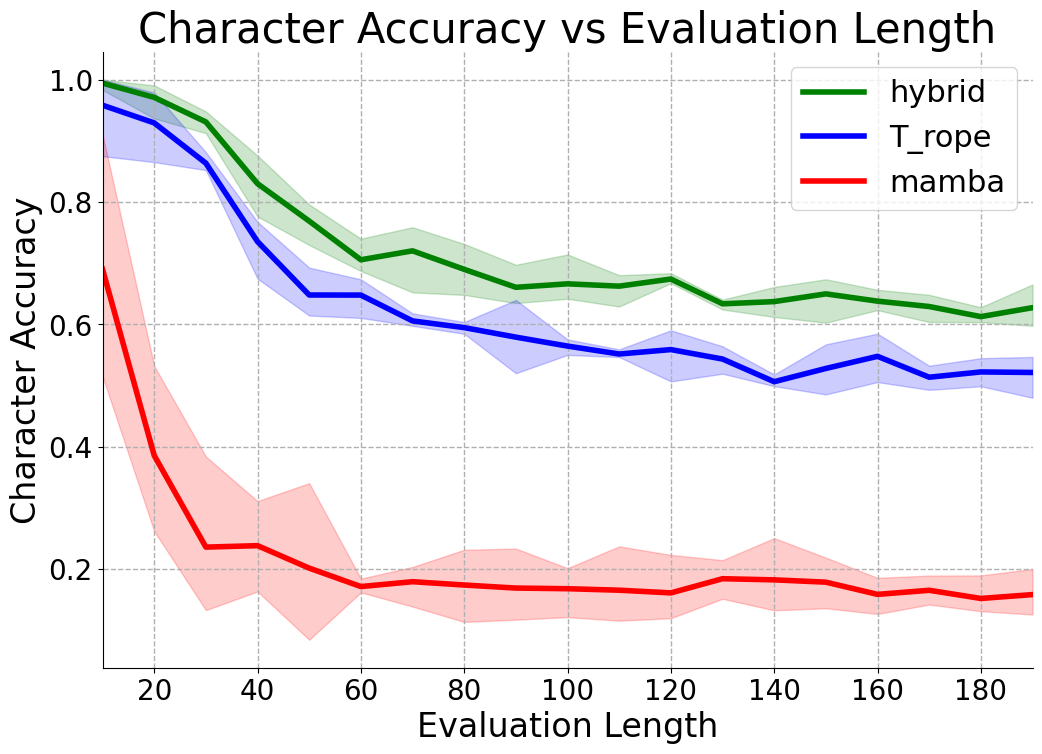

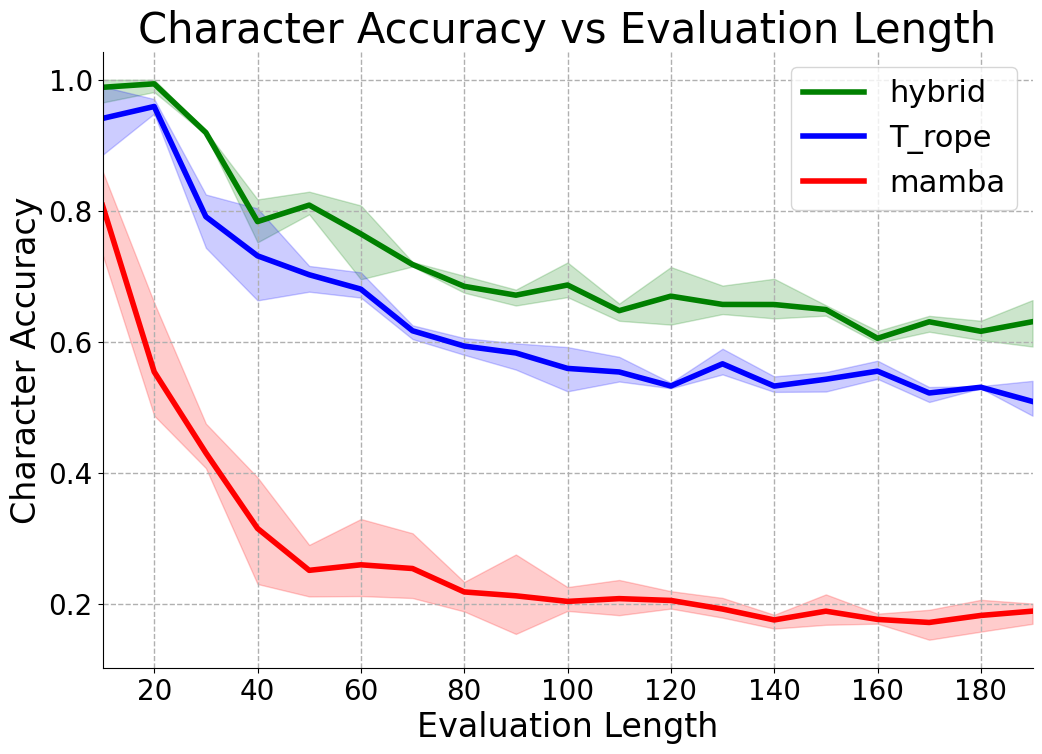

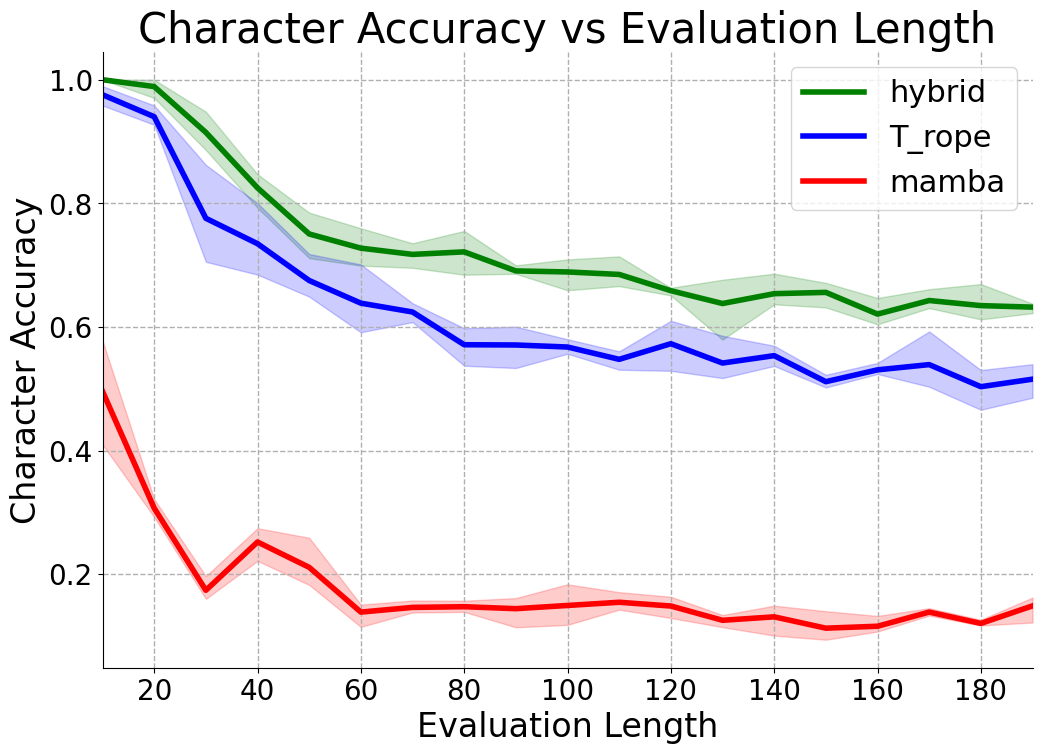

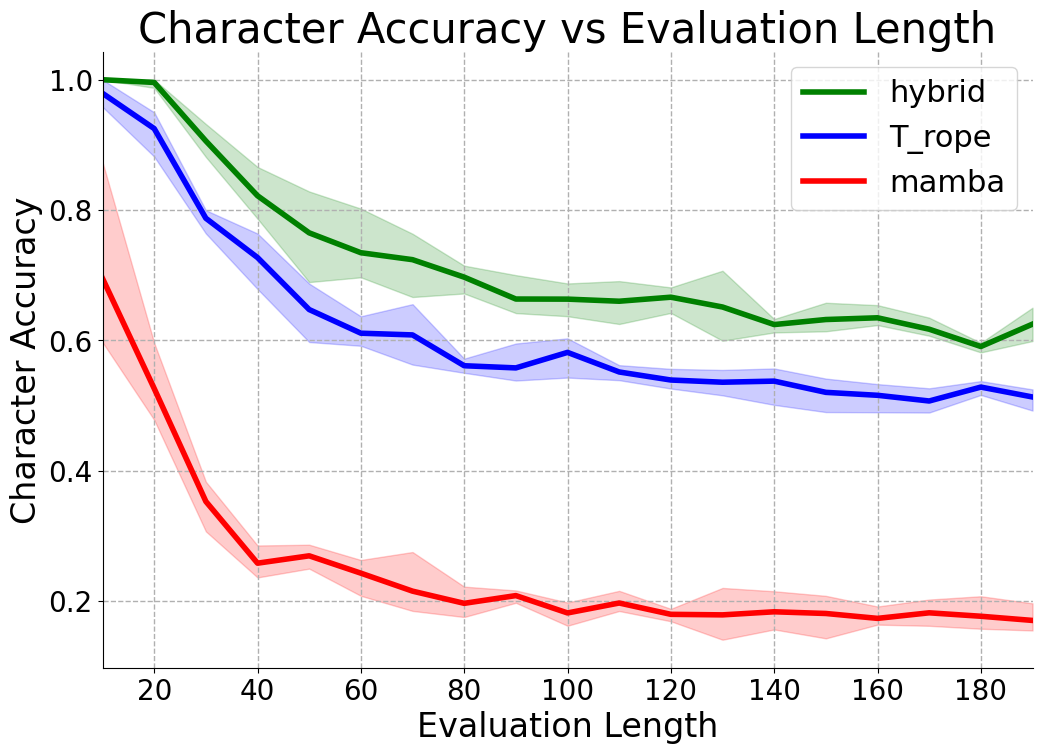

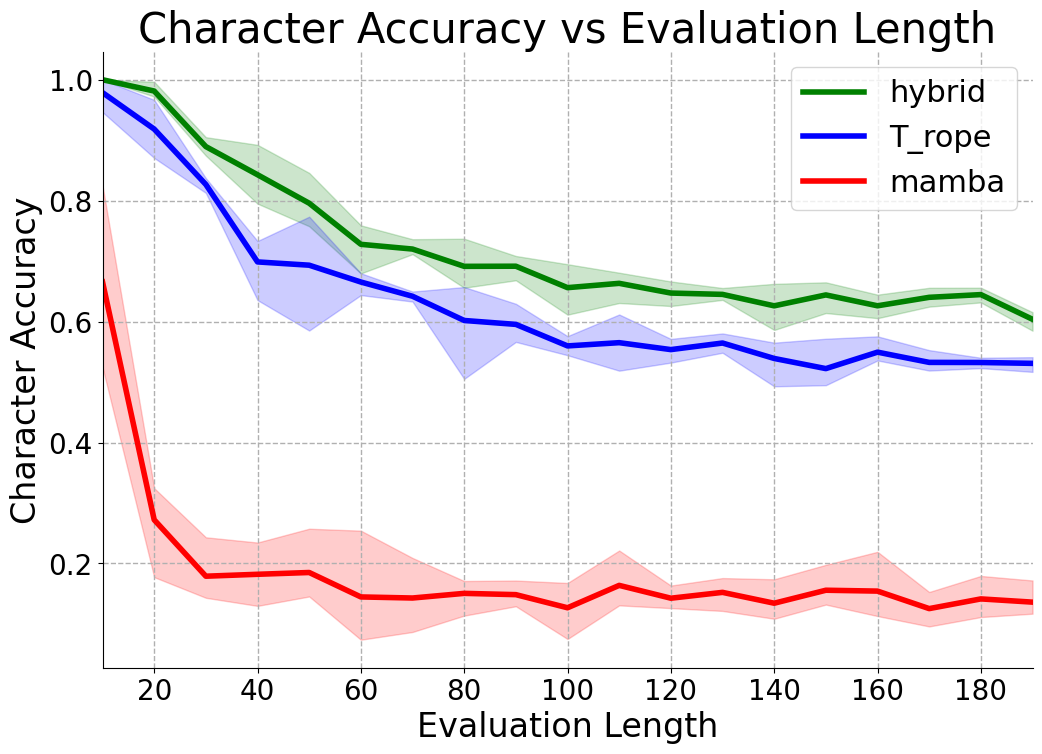

In [60]:
# plt.errorbar(keys, means, yerr=stds)
colors = {'T_rope': 'blue', 'hybrid': 'green', 'mamba': 'red'}

save = True

for p in accs.keys():
    for eval_p in accs[p].keys():
        plt.figure()
        for model in accs[p][eval_p].keys():
            plt.plot(keys[p][eval_p][model], means[p][eval_p][model], color=colors[model], label=model)

        plt.legend()

        for model in accs[p][eval_p].keys():
            plt.fill_between(keys[p][eval_p][model], mins[p][eval_p][model], maxs[p][eval_p][model], color=colors[model], alpha=0.2)

        plt.xlabel("Evaluation Length")
        plt.ylabel("Character Accuracy")
        plt.title("Character Accuracy vs Evaluation Length")
        # plt.title("Character Accuracy vs Evaluation Length - p=%s, eval_p=%s" % (p, eval_p))
        plt.grid('minor')

        if save:
            plt.savefig("results/fig/p_%s_eval_p_%s.png" % (p, eval_p))
            # save = False
# for eval_p in accs.keys():
#     plt.figure()
#     for model in accs[eval_p].keys():
#         plt.plot(keys[eval_p][model], means[eval_p][model], color=colors[model], linewidth=0.8, label=model)

#     plt.legend()

#     for model in accs[eval_p].keys():
#         plt.fill_between(keys[eval_p][model], mins[eval_p][model], maxs[eval_p][model], color=colors[model], alpha=0.2)

#     plt.xlabel("Evaluation Length")
#     plt.ylabel("Character Accuracy")
#     plt.title("Character Accuracy vs Evaluation Length - %s" % eval_p)
#     plt.grid('minor')

#     if save:
#         plt.savefig("results/fig/eval_p_%s.png" % eval_p)
#         save = False
# plt.show()